# 一文了解特征降维：从 PCA 到 LDA 的原理与实践

在机器学习领域，我们经常面对“高维”数据的挑战。随着特征维度的增加，数据在空间中的分布会变得极度稀疏，计算量呈指数级增长，且更容易陷入过拟合的泥潭——这就是著名的**维度灾难 (Curse of Dimensionality)**。

特征降维（Dimensionality Reduction）通过将高维数据映射到低维子空间，旨在保留数据核心信息的同时，消除冗余与噪声。这不仅能提升模型的计算效率，往往还能通过去噪提升模型的泛化能力。本文将深入探讨两类最经典的降维算法：**主成分分析 (PCA)** 与 **线性判别分析 (LDA)**，并延伸至 **Kernel PCA**、**Incremental PCA** 等进阶变体，从数学原理到工程实践，带你构建完整的降维知识体系。

---

## 1. 核心概念 —— 降维的定义、价值与工程视角

本章将系统阐述特征降维的基本定义，深入剖析“维度灾难”背后的数学机理，并重点梳理在工程落地过程中应用降维技术所需遵循的核心原则。

### 1.1 定义

特征降维是指通过某种数学变换 $\phi$，将原始高维特征空间 $X \in \mathbb{R}^n$ 映射到一个低维子空间 $Y \in \mathbb{R}^k$ ($k \ll n$) 的过程。

$$ Y = \phi(X) $$

根据变换 $\phi$ 是否利用标签信息，降维可分为：

- **无监督降维**：如 `PCA` (Principal Component Analysis)。它仅关注特征本身的分布结构，不依赖样本标签。
- **有监督降维**：如 `LDA` (Linear Discriminant Analysis)。它利用样本标签信息，试图找到最有利于分类的投影方向。

根据 $\phi$ 是否为线性函数，可分为：

- **线性降维**：如 `PCA`, `LDA`。假设数据位于高维空间的一个线性子空间（平面或超平面）上。
- **非线性降维**：如 `Kernel PCA`, `t-SNE`, `Isomap`, `LLE`。假设数据位于高维空间的一个**非线性流形**（Manifold）上（例如卷曲的瑞士卷结构）。

### 1.2 维度灾难的数学本质

“维度灾难”不仅仅意味着计算量的指数级增长，更深层的挑战在于高维空间中几何性质的根本性异变。人类基于低维世界（2D/3D）建立的几何直觉在高维空间中往往完全失效，呈现出种种反直觉的特性。

#### 1.2.1 距离失效

在高维空间中，欧氏距离（Euclidean Distance）逐渐失效。对于高维单位超立方体中的随机点，最大距离与最小距离的比值随着维度增加趋向于 1。

数学上可以证明，对于 $d$ 维空间中的随机向量 $x_1, x_2$，其距离分布的方差随着 $d$ 的增加而减小。

$$ \lim*{d \to \infty} \frac{\text{dist}*{max} - \text{dist}_{min}}{\text{dist}_{min}} \to 0 $$

这意味着：**在高维空间中，最近邻和最远邻的区别变得微乎其微**。这使得基于距离的算法（如 KNN、K-Means）在高维空间中效果急剧下降，仿佛所有点之间的距离都相等。

#### 1.2.2 空间稀疏性

随着维度增加，样本密度呈指数级下降。要维持相同的样本密度，所需样本量需呈指数级增长。

例如，覆盖一维空间的 10% 区域只需 10% 的样本。而在 100 维空间中，需要 $0.1^{1/100} \approx 0.977$ 即 97.7% 的样本才能覆盖每一维的 10% 长度。

这意味着高维数据大部分都分布在空间的“边缘”。在训练模型时，由于样本极其稀疏，模型很难通过有限的样本捕捉到真实的概率分布，极易导致**过拟合**。

#### 1.2.3 超球体体积萎缩

一个半径为 $r$ 的 $d$ 维超球体的体积 $V_d(r)$ 与同半径的超立方体体积 $C_d(r)$ 之比，随着 $d \to \infty$ 趋近于 0。

$$ \lim\_{d \to \infty} \frac{V_d(r)}{C_d(r)} = 0 $$

这意味着高维空间中，绝大部分体积都集中在超球体之外、超立方体的“角落”里。对于高斯分布的数据，这意味着大多数样本实际上距离均值非常远，位于分布的“长尾”上。

### 1.3 工程原则

在将降维算法引入生产环境时，需恪守以下原则：

1. **先归一化，后降维**：`PCA` 和 `LDA` 都对特征尺度高度敏感。如果特征间量纲不同（如“身高”单位是 cm，数值在 170 左右；“收入”单位是元，数值在 10000 左右），方差大的特征（收入）将主导投影方向，导致降维结果严重有偏。
   **必须**在降维前使用 `StandardScaler` 进行标准化，使所有特征具有 0 均值和 1 方差。

2. **严防数据泄漏 (Data Leakage)**：降维模型的训练（`fit`）只能在**训练集**上进行。

   - **错误做法**：先对全量数据做 PCA，然后拆分训练/测试集。这会让测试集的信息（分布特性）泄露到训练集中。
   - **正确做法**：`X_train` -> `scaler.fit` -> `pca.fit` -> `pca.transform`。然后用训练好的 `scaler` 和 `pca` 对 `X_test` 进行 `transform`。

3. **保留解释性**：降维后的特征（如 Principal Component 1）往往是原始特征的线性组合，物理含义模糊。如果业务强依赖可解释性（如风控归因、医疗诊断），应谨慎使用降维，或使用 Sparse PCA 等变体来增加稀疏性，使每个主成分只由少数原始特征构成。

---

## 2. 无监督降维 —— 主成分分析 (PCA)

**主成分分析 (PCA)** 是目前应用最为广泛的无监督线性降维技术。其核心思想是通过线性投影，将原始高维数据映射到一个低维正交子空间中，并确保在这个低维空间里**最大程度地保留原始数据的方差信息**。

### 2.1 核心直觉：最大方差理论

试想一组在二维平面上呈椭圆形分布的数据点。若我们必须将这些点投影到一条一维直线上，哪条直线最能还原原始数据的分布特征？

PCA 指出最佳选择是**椭圆的长轴**方向。这是因为数据在长轴方向上的投影分布最广，即**方差最大**。在统计学中，方差代表了数据的差异性和区分度。选择长轴方向进行投影，能最大程度地保留点与点之间的相对位置关系；反之，若选择短轴方向，数据点会重叠挤压，导致关键结构信息丢失。

从信号处理的视角审视，这体现了 **“方差即信息”** 的原则。高方差方向通常对应着具有物理意义的有效信号（Signal），而低方差方向往往由随机噪声（Noise）主导。因此，PCA 降维的过程，实质上就是一种保留高信噪比分量、滤除低信噪比干扰的特征提取过程。

### 2.2 数学原理详解

PCA 的目标是找到一组新的正交基（Principal Components），使得数据在这些基上的投影方差最大。

#### 2.2.1 协方差矩阵

设数据矩阵为 $X \in \mathbb{R}^{m \times n}$，其中 $m$ 为样本数，$n$ 为特征数。

> **前提**：数据必须经过**中心化处理**（Zero-centered），即每一列特征的均值都为 0。

此时，样本协方差矩阵 $C$ 定义为：

$$ C = \frac{1}{m-1} X^T X $$

该矩阵 $C$ 是一个 $n \times n$ 的实对称矩阵，其几何与统计含义十分明确：

- **对角线元素** ($C_{ii}$): 对应第 $i$ 个特征的**方差**，刻画了该特征维度的离散程度。
- **非对角线元素** ($C_{ij}$): 对应第 $i$ 个与第 $j$ 个特征之间的**协方差**，刻画了两个特征维度的线性相关性（正值表示正相关，0 表示线性无关）。

#### 2.2.2 拉格朗日乘数法推导

我们的目标是寻找一个投影方向 $w \in \mathbb{R}^n$，使得数据投影到该方向后的方差最大。为了避免 $w$ 的模长无限增大导致方差无限大，必须施加约束 $||w||_2 = 1$。

**优化目标**：

- $$ \max\_{w} \quad w^T C w $$
- $$ \text{s.t.} \quad w^T w = 1 $$

**推导过程**：

构建拉格朗日函数 (Lagrangian)，引入拉格朗日乘子 $\lambda$：

$$ \mathcal{L}(w, \lambda) = w^T C w - \lambda (w^T w - 1) $$

对向量 $w$ 求偏导，并令导数为 0（利用矩阵求导公式 $\frac{\partial (x^T A x)}{\partial x} = 2Ax$）：

$$ \frac{\partial \mathcal{L}}{\partial w} = 2 C w - 2 \lambda w = 0 $$

$$ \Rightarrow C w = \lambda w $$

**结论**：

1. 上式正是线性代数中的**特征值方程**。这证明了：**最优投影方向 $w$ 必定是协方差矩阵 $C$ 的特征向量**。
2. 将 $C w = \lambda w$ 代入目标函数：
   $$ \text{Variance} = w^T C w = w^T (\lambda w) = \lambda (w^T w) = \lambda $$
   这表明：**投影后的方差直接等于对应的特征值 $\lambda$\*\*。

因此，要使得方差最大，我们必须选择**最大特征值** $\lambda_{max}$ 对应的特征向量作为第一主成分。同理，第二主成分对应第二大特征值，依此类推。

#### 2.2.3 奇异值分解 (SVD) —— 更稳健的实现

在实际工程实现中（包括 `sklearn`），通常不直接计算协方差矩阵 $C = X^T X$ 及其特征值，而是采用更为高效且稳健的 **奇异值分解 (Singular Value Decomposition, SVD)**。

对中心化后的数据矩阵 $X \in \mathbb{R}^{m \times n}$ 进行 SVD 分解：

$$ X = U \Sigma V^T $$

各矩阵含义如下：

- $U \in \mathbb{R}^{m \times m}$：左奇异向量矩阵，列向量为 $XX^T$ 的特征向量。
- $\Sigma \in \mathbb{R}^{m \times n}$：奇异值对角矩阵，对角线元素 $\sigma_i$ 为奇异值，且 $\sigma_1 \ge \sigma_2 \ge \dots \ge 0$。
- $V \in \mathbb{R}^{n \times n}$：右奇异向量矩阵，**其列向量即为我们需要求的 PCA 主成分（特征向量）**。

**奇异值与特征值的关系**：

$$ \lambda_i = \frac{\sigma_i^2}{m-1} $$

即协方差矩阵的特征值等于奇异值的平方除以 $m-1$。

**为什么工程上首选 SVD？**

1. **数值稳定性 (Numerical Stability)**：直接计算 $X^T X$ 会导致条件数（Condition Number）平方级增长，极易引入浮点误差，特别是在特征高度相关（多重共线性）时。SVD 直接对 $X$ 分解，避免了平方运算，数值精度更高。
2. **计算效率**：虽然标准 SVD 复杂度较高，但通过随机化 SVD (Randomized SVD) 等现代算法，可以在大规模稀疏矩阵上实现极速求解。`sklearn` 的 `PCA` 默认在数据量大时自动切换到 Randomized SVD。

#### 2.2.4 SVD 的几何解释

从几何视角来看，SVD 将数据矩阵 $X$ 的线性变换分解为三个独立的几何动作序列：

1. **$V^T$ (特征空间旋转)**：
   在 $n$ 维特征空间中进行一次旋转（或反射）。这一步旨在**对齐坐标轴**，将原本杂乱的原始特征轴旋转到数据的自然延伸方向（即主成分方向）。
2. **$\Sigma$ (各向异性缩放)**：
   沿新的坐标轴方向进行拉伸或压缩。奇异值 $\sigma_i$ 决定了拉伸幅度。$\sigma_i$ 越大，表示数据在该方向分布越“长”（方差越大）；$\sigma_i \approx 0$ 则意味着该方向上的数据被“压扁”了。
3. **$U$ (样本空间旋转)**：
   在 $m$ 维样本空间中进行旋转，最终确定数据点在空间中的绝对位置。

**PCA 的本质**：PCA 巧妙地利用了第一步变换 $V^T$。它抛弃了原始坐标系（Feature 1, Feature 2...），直接使用旋转后的新坐标系（PC1, PC2...）。在这个新坐标系中，数据各个维度的相关性被彻底消除（协方差为 0），且能量（方差）高度集中在前几个坐标轴上。

### 2.3 关键工程问题：如何选择 k 值？

在实际工程中，选择目标维度 $k$ 往往不是拍脑袋决定的，而是基于**信息保留度**的量化评估。最常用的方法是计算 **累计解释方差比 (Cumulative Explained Variance Ratio)**：

$$ \text{Ratio}_k = \frac{\sum_{i=1}^k \lambda*i}{\sum*{j=1}^n \lambda_j} $$

该公式衡量了前 $k$ 个主成分保留了原始数据多少比例的方差（信息）。

**工程实践策略**：

1. **阈值法**：设定一个预期的信息保留度（例如 95%），寻找满足 $\text{Ratio}_k \ge 0.95$ 的最小 $k$ 值。
2. **Scree Plot (碎石图)**：绘制 $k$ 与 $\lambda_k$ 的关系图，寻找“肘部点 (Elbow Point)”。肘部点之后的特征值通常衰减平缓，代表噪声，应予舍弃。

### 2.4 PCA 算法变体简介

针对不同的数据特性与业务需求，PCA 衍生出了多种变体。下表总结了三种最常用的 PCA 变体及其适用场景：

| **算法变体**                   | **核心痛点**                                                                | **解决方案与原理**                                                                                 | **典型应用场景**                     |
| :----------------------------- | :-------------------------------------------------------------------------- | :------------------------------------------------------------------------------------------------- | :----------------------------------- |
| **Kernel PCA** (核 PCA)        | **非线性数据**。标准 PCA 只能提取线性特征，无法处理如“瑞士卷”等非线性流形。 | **核技巧 (Kernel Trick)**。将数据映射到高维特征空间，在高维空间做线性 PCA。常用 RBF 核、多项式核。 | 图像去噪、复杂流形数据降维。         |
| **Incremental PCA** (增量 PCA) | **内存溢出**。海量数据无法一次性读入内存进行 SVD 分解。                     | **增量学习 (Incremental Learning)**。将数据分批次 (Mini-batch) 喂入模型，动态更新奇异值分解结果。  | 超大规模数据集、实时在线数据流处理。 |
| **Sparse PCA** (稀疏 PCA)      | **缺乏解释性**。标准主成分是所有原始特征的稠密线性组合，难以解释物理含义。  | **L1 正则化 (Lasso)**。强制部分投影系数为 0，使主成分仅由少数原始特征驱动。                        | 基因分析、金融风控等强解释性领域。   |

### 2.5 实战案例：利用 PCA 进行图像降噪

PCA 不仅可以用于压缩数据，还可以用于去除噪声。其核心原理是：**信号（Signal）通常集中在前 $k$ 个主成分中，而噪声（Noise）则分散在所有维度上**。通过丢弃方差较小的分量，我们可以“过滤”掉大部分噪声，同时保留主要特征。

以下代码展示了如何利用 PCA 对含噪手写数字进行修复：



原始维度: 64
降噪保留维度: 12 (压缩了 81.2% 的维度)


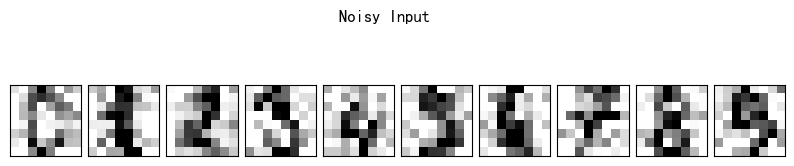

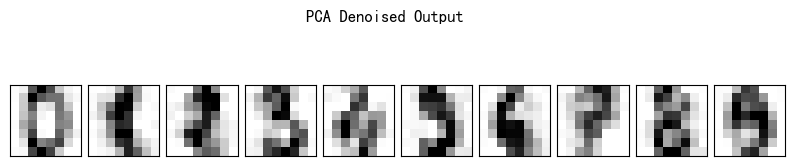

In [12]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

# 1. 数据准备：模拟“含噪”数据
digits = load_digits()
X_clean = digits.data
# 添加高斯白噪声 (Gaussian Noise)
np.random.seed(42)
X_noisy = X_clean + np.random.normal(loc=0, scale=4, size=X_clean.shape)

# 2. PCA 降噪
# 策略：仅保留 50% 的方差。这意味着我们丢弃了 50% 的信息（主要是噪声）
pca = PCA(n_components=0.50)
pca.fit(X_noisy)

# 变换到低维空间 (Filtering) -> 重构回原始空间 (Reconstruction)
X_components = pca.transform(X_noisy)
X_recovered = pca.inverse_transform(X_components)

print(f"原始维度: {X_noisy.shape[1]}")
print(f"降噪保留维度: {pca.n_components_} (压缩了 {1 - pca.n_components_/64:.1%} 的维度)")

# 3. 结果可视化
def plot_digits(data, title):
    fig, axes = plt.subplots(1, 10, figsize=(10, 2),
                             subplot_kw={'xticks':[], 'yticks':[]},
                             gridspec_kw=dict(hspace=0.1, wspace=0.1))
    for i, ax in enumerate(axes.flat):
        ax.imshow(data[i].reshape(8, 8),
                  cmap='binary', interpolation='nearest', clim=(0, 16))
    plt.suptitle(title, y=1.05)
    plt.show()

plot_digits(X_noisy[:10], 'Noisy Input')
plot_digits(X_recovered[:10], 'PCA Denoised Output')



> **案例解读**：
> 即使我们丢弃了近 80% 的维度（从 64 维降至十几维），重构后的数字不仅清晰可辨，而且背景中的杂乱噪点被显著平滑了。这证明了 PCA 成功捕获了数据的“主要结构”。

---

## 3. 有监督降维 —— 线性判别分析 (LDA)

**线性判别分析 (Linear Discriminant Analysis, LDA)** 是一种经典的**有监督**线性降维技术，同时也常被用作线性分类器。与 PCA 致力于“在低维空间最大程度保留原始数据的方差信息”不同，LDA 的核心使命是“**寻找一个投影子空间，使得不同类别的样本在该空间中可分性最大**”。

### 3.1 核心直觉：类内紧凑，类间分离

为了直观理解，不妨想象我们将一堆红球和蓝球混合撒在桌面上：

- **PCA 的视角**：它会寻找一个让球“铺得最开”的投影方向。虽然这保留了球体分布的整体轮廓，但红球和蓝球在投影轴上可能会混杂在一起，难以区分。
- **LDA 的视角**：它会寻找一个独特的投影角度，使得：
  1. **同类别的球尽可能紧抱成团**（类内方差最小化）。
  2. **红球群和蓝球群的中心尽可能离得远**（类间方差最大化）。

这一思想在数学上被形式化为 **Fisher 判别准则 (Fisher's Criterion)**：**最大化类间散度矩阵与类内散度矩阵的比值（广义瑞利商）**。

### 3.2 数学原理详解

为了将上述直觉转化为可计算的数学模型，LDA 定义了两个核心统计量——**散度矩阵 (Scatter Matrices)**。

#### 3.2.1 散度矩阵

假设数据集包含 $C$ 个类别，其中第 $i$ 类样本集合记为 $\omega_i$，该类别的样本均值向量为 $\mu_i$，所有样本的全局均值向量为 $\mu$。

1. **类内散度矩阵 (Within-class Scatter Matrix) $S_W$**：该矩阵量化了**每个类别内部样本的紧密度**。它本质上是各类别协方差矩阵的加权和。

   $$ S*W = \sum*{i=1}^{C} \sum\_{x \in \omega_i} (x - \mu_i)(x - \mu_i)^T $$

   **直观含义**：$S_W$ 越小，意味着同一类的样本点抱得越紧。

2. **类间散度矩阵 (Between-class Scatter Matrix) $S_B$**：该矩阵量化了**不同类别中心之间的分离度**。它计算的是各类别均值向量 $\mu_i$ 围绕全局均值 $\mu$ 的加权离散程度。

   $$ S*B = \sum*{i=1}^{C} N_i (\mu_i - \mu)(\mu_i - \mu)^T $$（其中 $N_i$ 是第 $i$ 类样本的数量）

   **直观含义**：$S_B$ 越大，意味着不同类别的中心隔得越远。

#### 3.2.2 广义特征值问题

LDA 的优化目标是寻找一个线性投影矩阵 $W$，使得投影后的类间散度最大化，同时类内散度最小化。数学上，这等价于最大化 **Fisher 判别准则** $J(W)$（即广义瑞利商）：

$$ J(W) = \frac{|W^T S_B W|}{|W^T S_W W|} $$

通过对 $W$ 求导并令梯度为 0，该最优化问题可转化为求解 **广义特征值问题 (Generalized Eigenvalue Problem)**：

$$ S_B w = \lambda S_W w $$

若 $S_W$ 可逆，上式可进一步转化为标准特征值问题：

$$ S_W^{-1} S_B w = \lambda w $$

**结论**：LDA 的最优投影方向 $w$ 正是矩阵 $S_W^{-1} S_B$ 的特征向量。对应的特征值 $\lambda$ 越大，表示该投影方向上的**判别能力 (Discriminative Power)** 越强。

#### 3.2.3 概率视角：为什么假设高斯分布？

除了 Fisher 判别准则的几何解释，LDA 还可以从**概率生成模型 (Generative Model)** 的角度理解。

LDA 本质上假设：

1. **高斯分布**：每个类别的样本都服从**多元高斯分布**。
2. **同协方差**：所有类别共享同一个**协方差矩阵** $\Sigma$（形状相同），但具有不同的均值中心 $\mu_k$。

基于贝叶斯定理，LDA 试图找到一个决策边界，使得样本属于某类的**后验概率** $P(y=k|x)$ 最大。数学推导表明，只有当满足上述“同协方差高斯分布”假设时，不同类别之间的最优决策边界才是**线性**的。这不仅解释了 LDA 名称中“Linear”的另一个来源，也揭示了其对数据分布极其敏感的根本原因。

### 3.3 关键工程问题：维度限制与小样本

在将 LDA 应用于工程实践时，必须警惕以下两个关键约束，它们直接决定了模型的可用性与性能。

#### 3.3.1 维度灾难

与 PCA 可以任意指定降维后的维度不同，**LDA 的输出维度 $k$ 存在天然上限：$k \le C-1$**（其中 $C$ 为类别数量）。

- **数学本质**：类间散度矩阵 $S_B$ 是由 $C$ 个类中心向量 $\mu_i$ 的线性组合构成的。由于这 $C$ 个向量受到一个线性约束（它们的加权和必须等于全局均值 $\mu$），导致 $S_B$ 的秩（Rank）最多只有 $C-1$。因此，只有前 $C-1$ 个特征值是非零的。
- **工程影响**：这意味着对于**二分类问题 ($C=2$)**，无论原始特征维度多高（例如 10000 维），LDA 强制将其压缩到 **1 维**。这一特性使得 LDA 在二分类场景下更像是一个“分类器”而非通用的“降维工具”。

#### 3.3.2 小样本问题 (SSS Problem)

当样本量 $N$ 小于特征维度 $D$（即 $N \ll D$ 的“高维小样本”场景）时，类内散度矩阵 $S_W$ 往往是奇异的（不可逆），导致无法求解广义特征值问题。这就是经典的 **Small Sample Size (SSS)** 问题。

**解决方案**：**引入正则化 (Regularization/Shrinkage)**。

其核心思想与 Ridge Regression 一致：通过向 $S_W$ 的主对角线添加一个微小的正数 $\alpha$，强制矩阵变得满秩且数值稳定：

$$ S_W(\alpha) = (1-\alpha) S_W + \alpha I $$

> **Code Tip**: 在 `sklearn` 中，推荐设置 `LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')`。这会自动利用 Ledoit-Wolf 引理估算最优收缩系数 $\alpha$，无需人工调参。

### 3.4 算法变体与对比

为了应对不同的数据分布和任务需求，LDA 发展出了多种变体（如 QDA）。同时，明确 LDA 与 PCA 的适用边界对于模型选型至关重要。下表对这两种核心降维算法进行了多维度对比：

| **对比维度** | **PCA (主成分分析)**                   | **LDA (线性判别分析)**                  |
| :----------- | :------------------------------------- | :-------------------------------------- |
| **算法类型** | **无监督**                             | **有监督**                              |
| **核心目标** | **保留全局方差** (Signal Preservation) | **最大化类间分离** (Class Separation)   |
| **适用场景** | 探索性分析、图像去噪、通用特征压缩     | 分类任务前的预处理、提升分类边界清晰度  |
| **对异常值** | 敏感 (方差会被离群点拉大)              | 较鲁棒 (关注类中心)，但受非高斯分布影响 |
| **分布假设** | 无严格假设 (但对高斯分布效果最佳)      | 假设各类别服从**同协方差的高斯分布**    |

### 3.5 实战案例：Wine 数据集上的 PCA vs LDA

下面的代码直观对比了在 Wine 数据集（13 维特征，3 个类别）上，PCA 和 LDA 降维到 2D 后的效果。



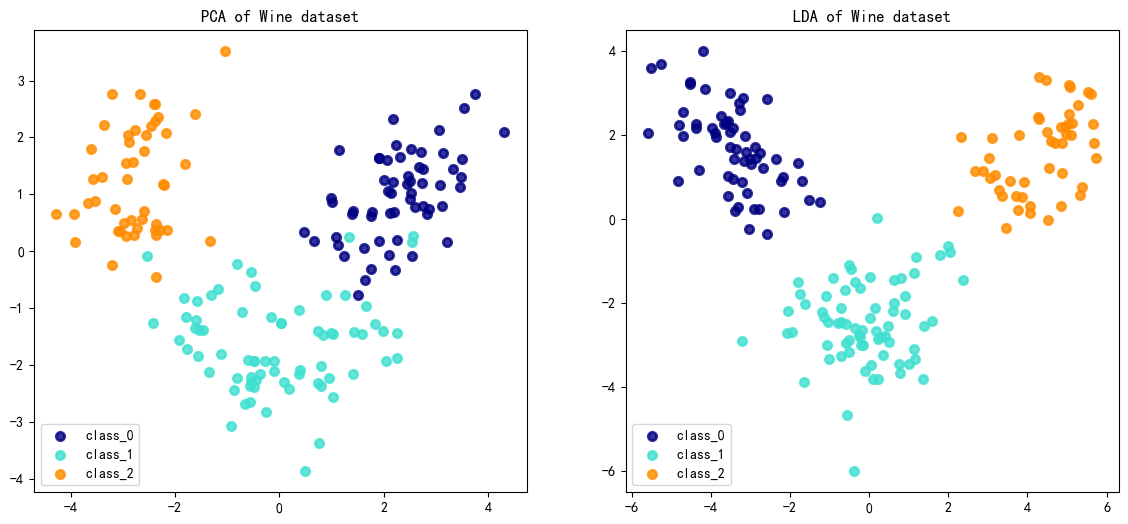

In [13]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 1. 准备数据
wine = load_wine()
X, y = wine.data, wine.target
target_names = wine.target_names

# 标准化 (对 PCA 尤为重要，对 LDA 也有益)
X_scaled = StandardScaler().fit_transform(X)

# 2. 降维对比
# PCA: 无监督，只看方差
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# LDA: 有监督，利用类别标签
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# 3. 可视化对比
plt.figure(figsize=(14, 6))

# 绘制 PCA 结果
plt.subplot(1, 2, 1)
colors = ['navy', 'turquoise', 'darkorange']
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, alpha=.8, lw=2,
                label=target_name)
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA of Wine dataset')

# 绘制 LDA 结果
plt.subplot(1, 2, 2)
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], color=color, alpha=.8, lw=2,
                label=target_name)
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('LDA of Wine dataset')

plt.show()



> **最佳实践**：
> 如果你的任务是**分类**，且类别标签可用，优先尝试 **LDA**。但要注意 LDA 对数据分布（高斯分布、同协方差）的假设比 PCA 更强，如果数据严重违背这些假设，PCA 可能会表现更好。

---

## 4. 实战案例：红酒数据集 (Wine Dataset) 深度剖析

为了直观对比 PCA 和 LDA 的效果，我们使用经典的 Wine 数据集。该数据集包含 178 个样本，13 个化学特征，分为 3 类。

### 4.1 数据准备与预处理



In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 1. 加载数据
wine = load_wine()
X, y = wine.data, wine.target
target_names = wine.target_names

# 2. 标准化 (至关重要)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



### 4.2 PCA vs LDA 降维可视化

我们将 13 维数据分别降维到 2 维，观察其分布。



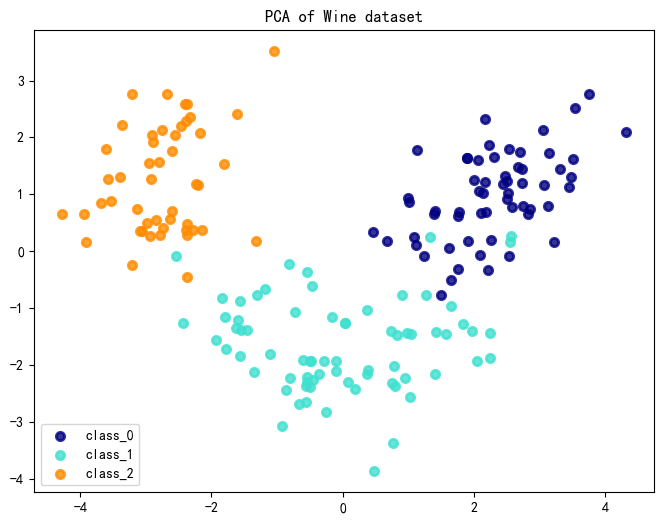

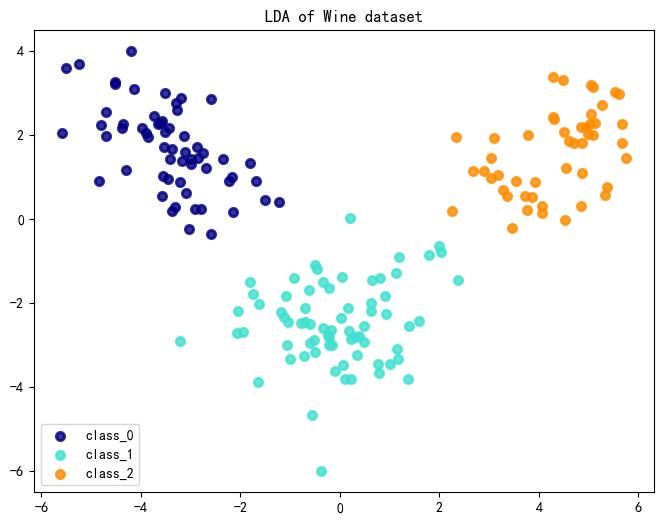

In [15]:
# PCA 降维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# LDA 降维
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y) # 注意：LDA 需要标签 y

# 可视化函数
def plot_embedding(X, title):
    plt.figure(figsize=(8, 6))
    colors = ['navy', 'turquoise', 'darkorange']
    for color, i, target_name in zip(colors, [0, 1, 2], target_names):
        plt.scatter(X[y == i, 0], X[y == i, 1], color=color, alpha=.8, lw=2,
                    label=target_name)
    plt.legend(loc='best', shadow=False, scatterpoints=1)
    plt.title(title)
    plt.show()

# 执行可视化
plot_embedding(X_pca, 'PCA of Wine dataset')
plot_embedding(X_lda, 'LDA of Wine dataset')



### 4.3 结果分析

- **PCA 结果**：样本点在 2D 空间中分布较为分散，保留了数据的整体结构。但是，不同类别的样本（特别是类别 1 和类别 2）存在一定的重叠。这是因为 PCA 只关注方差（主要由特征间的相关性决定），而不关心类别是否可分。
- **LDA 结果**：不同类别的样本被极其清晰地分开了，类内非常紧凑，类间距离很大。这是因为 LDA 显式地优化了 Fisher 准则，找到了区分度最强的方向。

### 4.4 性能实测：Raw vs PCA vs LDA

光看可视化不够，我们还需要用分类器来量化降维的效果。我们使用简单的逻辑回归（Logistic Regression）作为基准分类器。



In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression  # Added missing import

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 1. Baseline: 原始特征 (13维)
clf_raw = LogisticRegression(solver='lbfgs', max_iter=200) # 使用 lbfgs 求解器，支持多分类
clf_raw.fit(X_train, y_train)
acc_raw = accuracy_score(y_test, clf_raw.predict(X_test))

# 2. PCA (2维)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test) # 注意：测试集只能 transform

clf_pca = LogisticRegression(solver='lbfgs', max_iter=200)
clf_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, clf_pca.predict(X_test_pca))

# 3. LDA (2维)
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

clf_lda = LogisticRegression(solver='lbfgs', max_iter=200)
clf_lda.fit(X_train_lda, y_train)
acc_lda = accuracy_score(y_test, clf_lda.predict(X_test_lda))

print(f"原始特征准确率 (13维): {acc_raw:.4f}")
print(f"PCA 特征准确率 (2维):  {acc_pca:.4f}")
print(f"LDA 特征准确率 (2维):  {acc_lda:.4f}")

原始特征准确率 (13维): 0.9815
PCA 特征准确率 (2维):  0.9630
LDA 特征准确率 (2维):  0.9815




**典型输出分析**：

- **原始特征**：准确率通常很高（~98%），因为红酒数据集特征包含丰富信息。
- **PCA (2 维)**：准确率可能会有所下降（~96%），因为我们丢弃了部分方差信息，且 PCA 不保证保留分类边界。但在可视化和计算效率上有巨大优势。
- **LDA (2 维)**：准确率通常能与原始特征持平甚至更高（~98%-100%）。因为 LDA 剔除了与分类无关的噪声，直接提取了最强判别特征。

### 4.5 解释方差对比



In [17]:
print(f"PCA 解释方差比: {pca.explained_variance_ratio_}")
print(f"LDA 解释方差比: {lda.explained_variance_ratio_}")

PCA 解释方差比: [0.36534816 0.18061255]
LDA 解释方差比: [0.69340706 0.30659294]




通常你会发现，PCA 的前两个主成分解释了约 50%-60% 的总方差，而 LDA 的前两个分量（如果有的话）解释的方差通常不能直接这样比较，但它们提供了 100% 的类间判别力（在 2D 子空间中）。

---

## 5. 深度对比

面对实际业务中的高维数据，如何选择合适的降维算法往往决定了后续模型的上限。选型不仅取决于**标签是否可用**（有监督 vs 无监督），还需要综合考量数据的**分布特性**（线性 vs 非线性）、**计算资源限制**以及**下游任务目标**（可视化 vs 特征压缩 vs 分类）。以下是一份详尽的 PCA 与 LDA 深度对比及选型指南，助你在工程实践中做出最优决策。

| **对比维度**   | **PCA (主成分分析)**             | **LDA (线性判别分析)**                       |
| :------------- | :------------------------------- | :------------------------------------------- |
| **核心目标**   | 最大化数据整体方差 (Variance)    | 最大化类间区分度 (Separability)              |
| **监督类型**   | **无监督** (Unsupervised)        | **有监督** (Supervised)                      |
| **几何直觉**   | 寻找数据分布最“散”的方向         | 寻找让同类最“聚”、异类最“开”的方向           |
| **降维上限**   | 原始特征维数 $n$                 | 类别数减一 $C-1$                             |
| **数据假设**   | 无严格假设，但对高斯分布效果最好 | 严格假设数据服从高斯分布，且各类别协方差相等 |
| **对异常值**   | 敏感（方差会被离群点拉大）       | 敏感（均值和方差均受影响）                   |
| **计算复杂度** | 较低，适合超大规模数据           | 较高（涉及矩阵求逆），且受限于样本量         |
| **典型场景**   | 图像去噪、探索性分析、特征解耦   | 分类任务预处理、特征鉴别                     |

---

## 6. FAQ

**Q1: 降维一定会提升模型性能吗？**
A: **绝对不是**。降维本质上是信息有损压缩。

- **正面案例**：当数据存在大量噪声或多重共线性时，降维能过滤噪声，提升模型泛化能力。
- **负面案例**：如果原本特征就很少且都很重要，强行降维会丢失关键信息，导致欠拟合。
  降维的主要收益通常是计算效率、可视化可行性和防过拟合，而非单纯提升准确率。

**Q2: 应该先做 PCA 还是先做特征选择 (Feature Selection)？**
A: 两者逻辑不同，视业务需求而定。

- **特征选择 (Lasso, Random Forest Importance)**：做“减法”，保留原始特征子集。**物理含义明确**，适合需要解释性的场景。
- **PCA**：做“变换”，生成全新的特征组合。**物理含义模糊**，适合纯预测或去相关场景。
  如果特征维度极高（如 10 万+），通常先用简单的特征选择（如方差过滤）粗筛，再用 PCA 精细降维。

**Q3: 如何处理非数值型特征（Categorical Features）？**
A: PCA 和 LDA 都是基于代数运算的，**只能处理数值型数据**。
对于类别特征，必须先进行编码：

- **OrdinalEncoder**：用于有序类别（如 高/中/低）。
- **OneHotEncoder**：用于无序类别（如 红色/蓝色）。注意 OneHot 会急剧增加维度，此时配合 PCA 降维是一个经典组合。
- **Embedding**：对于高维稀疏类别（如 User ID），建议使用神经网络 Embedding 降维，而非 PCA。

**Q4: t-SNE 和 PCA 有什么区别？为什么 t-SNE 不能用于特征工程？**
A:

- **PCA** 是参数化的线性变换，学习到一个投影矩阵，可以应用到新样本上。
- **t-SNE** 是一种非参数化的流形学习方法，主要用于**数据可视化**。它只能将当前数据映射到 2D/3D，无法直接对新样本进行转换（虽然有变体支持，但计算极慢）。
  **结论**：特征工程选 PCA/LDA，做 PPT 展示选 t-SNE/UMAP。

---

## 参考文献

[1] Bishop, C. M. (2006). _Pattern Recognition and Machine Learning_. Springer. (Chapter 12)
[2] Hastie, T., Tibshirani, R., & Friedman, J. (2009). _The Elements of Statistical Learning_. Springer.
[3] Fisher, R. A. (1936). The use of multiple measurements in taxonomic problems. _Annals of Eugenics_.
[4] Jolliffe, I. T. (2002). _Principal Component Analysis_. Springer.
[5] Scikit-learn Documentation. "Decomposition: principal component analysis (PCA)".
